In [76]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [77]:
BASE_DIR = Path(r"C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale")

BASELINE_FILE = BASE_DIR / "baseline_topology_only_embeddings.csv"
GEOM_CONTEXT_FILE = BASE_DIR / "geom_context_with_coords_embeddings.csv"
FULL_FILE = BASE_DIR / "full_with_coords_embeddings.csv"
NODE_FILE = BASE_DIR / "lgia_riga_nodes_enriched_osm.csv"

for f in [BASELINE_FILE, GEOM_CONTEXT_FILE, FULL_FILE, NODE_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"Missing required file: {f}")

baseline_df = pd.read_csv(BASELINE_FILE)
geom_context_df = pd.read_csv(GEOM_CONTEXT_FILE)
full_df = pd.read_csv(FULL_FILE)
nodes_df = pd.read_csv(NODE_FILE)

print("baseline_df:", baseline_df.shape)
print("geom_context_df:", geom_context_df.shape)
print("full_df:", full_df.shape)
print("nodes_df:", nodes_df.shape)

baseline_df: (136, 33)
geom_context_df: (136, 33)
full_df: (136, 33)
nodes_df: (136, 47)


In [78]:
embedding_dfs = {
    "baseline_topology_only": baseline_df,
    "geom_osm_with_coords": geom_context_df,
    "full_with_coords": full_df,
}

In [79]:
# All embedding tables are aligned to the same node order before evaluation.
nodes_df["node_id"] = nodes_df["node_id"].astype(str)

for model_name in embedding_dfs:
    embedding_dfs[model_name]["node_id"] = embedding_dfs[model_name]["node_id"].astype(str)

common_nodes = set(nodes_df["node_id"])

for df in embedding_dfs.values():
    common_nodes &= set(df["node_id"])

nodes_df = (
    nodes_df[nodes_df["node_id"].isin(common_nodes)]
    .reset_index(drop=True)
)

node_order = nodes_df["node_id"].tolist()

geo_coords = nodes_df[["centroid_x", "centroid_y"]].to_numpy(dtype=np.float32)

embedding_arrays = {
    model_name: (
        df.set_index("node_id")
        .loc[node_order]
        .to_numpy(dtype=np.float32)
    )
    for model_name, df in embedding_dfs.items()
}

print("Common nodes across all embeddings and nodes_df:", len(node_order))
print("geo_coords:", geo_coords.shape)

for model_name, arr in embedding_arrays.items():
    print(f"{model_name}: {arr.shape}")

Common nodes across all embeddings and nodes_df: 136
geo_coords: (136, 2)
baseline_topology_only: (136, 32)
geom_osm_with_coords: (136, 32)
full_with_coords: (136, 32)


In [80]:
MAX_K = 20

geo_nn = NearestNeighbors(n_neighbors=MAX_K + 1, metric="euclidean")
geo_nn.fit(geo_coords)
_, geo_indices = geo_nn.kneighbors(geo_coords)

In [81]:
def recall_at_k(geographic_neighbor_indices, embedding_neighbor_indices, k_value):
    recall_values = []

    for i in range(len(geographic_neighbor_indices)):
        geographic_neighbors = set(geographic_neighbor_indices[i][1:k_value + 1])
        embedding_neighbors = set(embedding_neighbor_indices[i][1:k_value + 1])

        if len(geographic_neighbors) == 0:
            recall_values.append(0.0)
        else:
            matched_neighbors = len(geographic_neighbors & embedding_neighbors)
            recall_values.append(matched_neighbors / len(geographic_neighbors)            )

    return float(np.mean(recall_values))

In [82]:
def evaluate_recall_scores(
        geo_indices,
        vec_matrix,
        max_neighbours=20,
        k_values=(5, 10, 20)
    ):
    vec_nearest_neighbour_model = NearestNeighbors(
        n_neighbors=max_neighbours + 1,
        metric="euclidean"
    )

    vec_nearest_neighbour_model.fit(vec_matrix)
    _, vec_indices = vec_nearest_neighbour_model.kneighbors(vec_matrix)

    recall_results = {}

    for k_value in k_values:
        recall_results[f"Recall@{k_value}"] = recall_at_k(geo_indices, vec_indices, k_value)

    return recall_results, vec_indices

In [83]:
def evaluate_distance_preservation(
        geo_coords,
        node_vectors,
        sample_size=5000,
        random_state=42
    ):
    rng = np.random.default_rng(random_state)
    number_of_nodes = len(geo_coords)

    source_idx = rng.integers(0, number_of_nodes, size=sample_size)
    target_idx = rng.integers(0, number_of_nodes, size=sample_size)

    valid_pair_mask = source_idx != target_idx
    source_idx = source_idx[valid_pair_mask]
    target_idx = target_idx[valid_pair_mask]

    geo_dist = np.linalg.norm(
        geo_coords[source_idx] - geo_coords[target_idx],
        axis=1
    )

    vec_dist = np.linalg.norm(
        node_vectors[source_idx] - node_vectors[target_idx],
        axis=1
    )

    spearman_corr, _ = spearmanr(geo_dist, vec_dist)
    pearson_corr, _ = pearsonr(geo_dist, vec_dist)

    return {
        "spearman": float(spearman_corr),
        "pearson": float(pearson_corr),
        "geo_dist": geo_dist,
        "vec_dist": vec_dist,
    }

In [84]:
def minmax_normalize(x):
    x = np.asarray(x, dtype=float)
    x_min = x.min()
    x_max = x.max()

    if x_max - x_min == 0:
        return np.zeros_like(x)

    return (x - x_min) / (x_max - x_min)

In [85]:
def evaluate_rmse(geo_dist, emb_dist):
    geo_norm = minmax_normalize(geo_dist)
    emb_norm = minmax_normalize(emb_dist)
    return float(np.sqrt(mean_squared_error(geo_norm, emb_norm)))

In [86]:
evaluation_rows = []
all_recall_results = {}
all_distance_results = {}

for model_name, emb in embedding_arrays.items():
    recall_scores, emb_indices = evaluate_recall_scores(
        geo_indices=geo_indices,
        vec_matrix=emb,
        max_neighbours=MAX_K,
        k_values=(5, 10, 20)
    )

    distance_scores = evaluate_distance_preservation(
        geo_coords=geo_coords,
        node_vectors=emb,
        sample_size=5000,
        random_state=42
    )

    rmse_value = evaluate_rmse(
        geo_dist=distance_scores["geo_dist"],
        emb_dist=distance_scores["vec_dist"]
    )

    all_recall_results[model_name] = recall_scores
    all_distance_results[model_name] = distance_scores

    evaluation_rows.append({
        "Model": model_name,
        **recall_scores,
        "Spearman": distance_scores["spearman"],
        "Pearson": distance_scores["pearson"],
        "RMSE": rmse_value,
    })

results_exact_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values("Model")
    .reset_index(drop=True)
)

results_exact_df

,Model,Recall@5,Recall@10,Recall@20,Spearman,Pearson,RMSE
0,baseline_topology_only,0.051471,0.102206,0.179044,0.036329,0.033696,0.261925
1,full_with_coords,0.808824,0.871324,0.898897,0.976851,0.970661,0.041470
2,geom_osm_with_coords,0.805882,0.861029,0.902206,0.973757,0.971604,0.063517


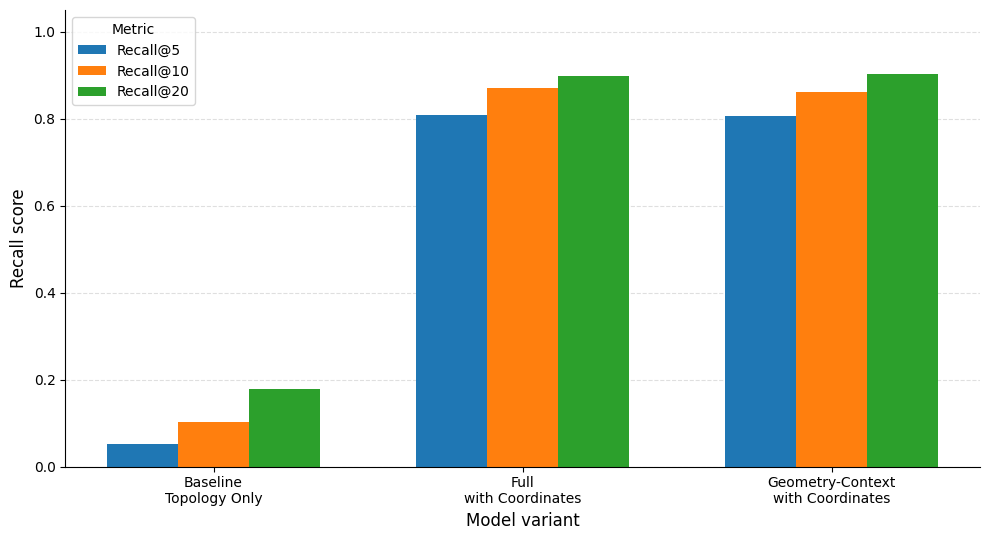

In [87]:
# Data
models = results_exact_df["Model"].tolist()
recall5 = results_exact_df["Recall@5"].tolist()
recall10 = results_exact_df["Recall@10"].tolist()
recall20 = results_exact_df["Recall@20"].tolist()

# Cleaner display labels
model_labels = [
    m.replace("baseline_topology_only", "Baseline\nTopology Only")
     .replace("full_with_coords", "Full\nwith Coordinates")
     .replace("geom_osm_with_coords", "Geometry-Context\nwith Coordinates")
    for m in models
]

x = np.arange(len(models))
width = 0.23

fig, ax = plt.subplots(figsize=(10, 5.5))

bars1 = ax.bar(x - width, recall5, width, label="Recall@5")
bars2 = ax.bar(x, recall10, width, label="Recall@10")
bars3 = ax.bar(x + width, recall20, width, label="Recall@20")

# Labels and title
ax.set_ylabel("Recall score", fontsize=12)
ax.set_xlabel("Model variant", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)

# Recall is between 0 and 1
ax.set_ylim(0, 1.05)

# Horizontal grid for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Metric",
    frameon=True,
    loc="upper left"
)

plt.tight_layout()
plt.show()

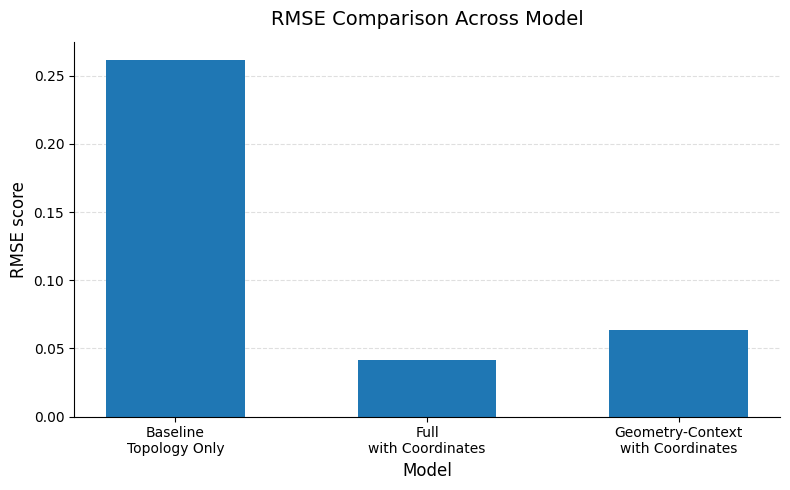

In [88]:
models = results_exact_df["Model"].tolist()
rmse_values = results_exact_df["RMSE"].tolist()

model_labels = [
    m.replace("baseline_topology_only", "Baseline\nTopology Only")
     .replace("full_with_coords", "Full\nwith Coordinates")
     .replace("geom_osm_with_coords", "Geometry-Context\nwith Coordinates")
    for m in models
]

x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x, rmse_values, width=0.55)

ax.set_title("RMSE Comparison Across Model", fontsize=14, pad=12)
ax.set_ylabel("RMSE score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.show()

In [89]:
print("Main evaluation table using exact vector search:")
display(results_exact_df)

Main evaluation table using exact vector search:


,Model,Recall@5,Recall@10,Recall@20,Spearman,Pearson,RMSE
0,baseline_topology_only,0.051471,0.102206,0.179044,0.036329,0.033696,0.261925
1,full_with_coords,0.808824,0.871324,0.898897,0.976851,0.970661,0.041470
2,geom_osm_with_coords,0.805882,0.861029,0.902206,0.973757,0.971604,0.063517


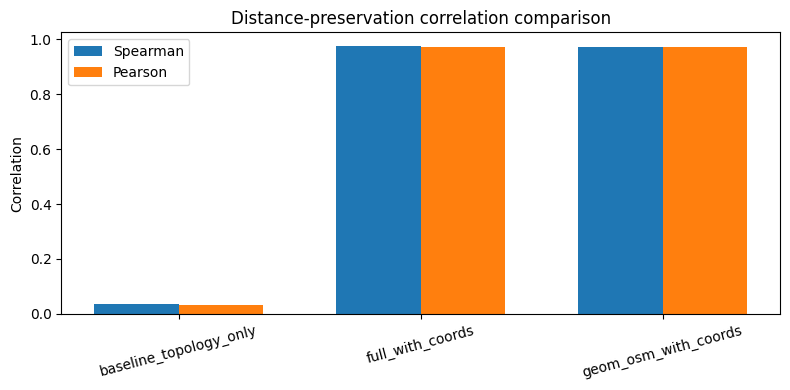

In [90]:
x = np.arange(len(results_exact_df))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, results_exact_df["Spearman"], width, label="Spearman")
plt.bar(x + width/2, results_exact_df["Pearson"], width, label="Pearson")

plt.xticks(x, results_exact_df["Model"], rotation=15)
plt.ylabel("Correlation")
plt.title("Distance-preservation correlation comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
def get_node_info(node_index):
    row = nodes_df.iloc[node_index]

    info = {
        "node_index": node_index,
        "node_id": row["node_id"],
    }

    optional_columns = [
        "class_code",
        "class_label",
        "class_lvl1",
        "class_lvl2",
        "class_lvl3",
        "area_m2",
        "perimeter_m",
        "amenity_count",
        "road_length_in_poly_m",
        "nearest_road_dist_m",
        "building_count",
        "shop_count",
        "leisure_count",
        "public_transport_count",
    ]

    for col in optional_columns:
        if col in nodes_df.columns:
            info[col] = row[col]

    return info

In [92]:
def find_query_anchor(query_node_id):
    query_node_id = str(query_node_id)
    query_index = int(nodes_df.index[nodes_df["node_id"].astype(str) == query_node_id][0])
    query_coord = geo_coords[query_index]

    return {
        "query_type": "selected_node",
        "query_index": query_index,
        "query_node_id": nodes_df.iloc[query_index]["node_id"],
        "query_coord": query_coord,
        "anchor_index": query_index,
        "anchor_node_id": nodes_df.iloc[query_index]["node_id"],
    }

In [93]:
def direct_geographic_search(query_coord, anchor_index=None, k=5):
    distances = np.linalg.norm(geo_coords - query_coord, axis=1)
    ordered_indices = np.argsort(distances)

    results = []

    for idx in ordered_indices:
        if anchor_index is not None and idx == anchor_index:
            continue

        results.append({
            "retrieved_index": int(idx),
            "retrieval_distance": float(distances[idx]),
        })

        if len(results) == k:
            break

    return results

In [94]:
def embedding_search(model_name, anchor_index, k=5):
    representation = embedding_arrays[model_name]

    nn_model = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean"
    )

    nn_model.fit(representation)

    query_vector = representation[anchor_index].reshape(1, -1)

    distances, indices = nn_model.kneighbors(query_vector)

    results = []

    for dist, idx in zip(distances[0], indices[0]):
        if idx == anchor_index:
            continue

        results.append({
            "retrieved_index": int(idx),
            "retrieval_distance": float(dist),
        })

        if len(results) == k:
            break

    return results

In [95]:
def build_query_result_table(
    approach_name,
    results,
    query_coord,
    ground_truth_indices=None
):
    rows = []

    for rank, item in enumerate(results, start=1):
        retrieved_index = item["retrieved_index"]
        node_info = get_node_info(retrieved_index)

        geo_distance_to_query = np.linalg.norm(
            geo_coords[retrieved_index] - query_coord
        )

        row = {
            "approach": approach_name,
            "rank": rank,
            "retrieved_node_id": node_info["node_id"],
            "geo_distance_to_query_m": float(geo_distance_to_query),
            "retrieval_distance": item["retrieval_distance"],
        }

        if ground_truth_indices is not None:
            row["is_geographic_match"] = retrieved_index in ground_truth_indices

        for key, value in node_info.items():
            if key not in ["node_index", "node_id"]:
                row[key] = value

        rows.append(row)

    return pd.DataFrame(rows)

In [96]:
def run_realistic_nearby_query(query_node_id, k=5):
    anchor = find_query_anchor(query_node_id)

    query_coord = anchor["query_coord"]
    anchor_index = anchor["anchor_index"]

    summary_rows = []
    detail_rows = []

    # Direct geographic reference search
    geo_distances = np.linalg.norm(geo_coords - query_coord, axis=1)
    geo_order = np.argsort(geo_distances)
    geo_neighbors = geo_order[geo_order != anchor_index][:k]

    reference_set = set(geo_neighbors)

    summary_rows.append({
        "Approach": "Direct geographic search",
        "Query Recall@5": 1.00,
        "Matched geographic neighbors": k,
        "Average distance in meters": geo_distances[geo_neighbors].mean()
    })

    for rank, idx in enumerate(geo_neighbors, start=1):
        detail_rows.append({
            "Approach": "Direct geographic search",
            "Rank": rank,
            "Node ID": nodes_df.iloc[idx]["node_id"],
            "Distance in meters": geo_distances[idx],
            "Matched geographic neighbor": True
        })

    # Embedding searches
    approach_labels = {
        "baseline_topology_only": "Baseline model",
        "geom_osm_with_coords": "First enhanced embedding",
        "full_with_coords": "Second enhanced embedding"
    }

    for model_name, model_label in approach_labels.items():
        emb = embedding_arrays[model_name]

        query_vector = emb[anchor_index]
        emb_distances = np.linalg.norm(emb - query_vector, axis=1)
        emb_order = np.argsort(emb_distances)
        emb_neighbors = emb_order[emb_order != anchor_index][:k]

        matched = len(reference_set.intersection(set(emb_neighbors)))
        recall_value = matched / k

        summary_rows.append({
            "Approach": model_label,
            "Query Recall@5": recall_value,
            "Matched geographic neighbors": matched,
            "Average distance in meters": geo_distances[emb_neighbors].mean()
        })

        for rank, idx in enumerate(emb_neighbors, start=1):
            detail_rows.append({
                "Approach": model_label,
                "Rank": rank,
                "Node ID": nodes_df.iloc[idx]["node_id"],
                "Distance in meters": geo_distances[idx],
                "Matched geographic neighbor": idx in reference_set
            })

    query_summary_df = pd.DataFrame(summary_rows)
    query_details_df = pd.DataFrame(detail_rows)

    return anchor, query_summary_df, query_details_df

In [97]:
example_node_id = nodes_df.iloc[0]["node_id"]

anchor, query_summary_df, query_details_df = run_realistic_nearby_query(
    query_node_id=example_node_id,
    k=5
)

display(query_summary_df)
display(query_details_df)

,Approach,Query Recall@5,Matched geographic neighbors,Average distance in meters
0,Direct geographic search,1.0,5,1405.292236
1,Baseline model,0.0,0,7791.609375
2,First enhanced embedding,0.8,4,1453.797974
3,Second enhanced embedding,0.6,3,1523.896973


,Approach,Rank,Node ID,Distance in meters,Matched geographic neighbor
0,Direct geographic search,1,61,606.818909,True
1,Direct geographic search,2,11,1307.132202,True
2,Direct geographic search,3,26,1616.145874,True
3,Direct geographic search,4,59,1733.520508,True
4,Direct geographic search,5,44,1762.843384,True
5,Baseline model,1,107,10256.752930,False
6,Baseline model,2,120,11743.356445,False
7,Baseline model,3,39,5921.474609,False
8,Baseline model,4,14,7482.960449,False
9,Baseline model,5,86,3553.505371,False
